# Telco Customer Churn — Prediction Project

Load → Cleaning → EDA → Train/Test Split → Imputation (بعد السبليت) → Encoding + Scaling (ColumnTransformer واحد) → Models (Logistic Regression / KNN / Random Forest) → Evaluation (Accuracy/Precision/Recall/F1/ROC-AUC) → ROC Curve → اختيار أفضل موديل → Confusion Matrix → Feature Importance → Conclusion.

## 1. Imports

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

## 2. تحميل البيانات


In [10]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. تنظيف البيانات

In [13]:
df.drop('customerID', axis=1, inplace=True)

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [15]:
df.columns = df.columns.str.lower()

In [16]:
df.churn = (df.churn == 'Yes').astype(int)
df.churn.value_counts()

,count
churn,
0,5174
1,1869


In [17]:
df['seniorcitizen'] = df['seniorcitizen'].astype('object')

In [18]:
categorical = list(df.select_dtypes(include=['object']).columns)
numerical = list(df.select_dtypes(include=['number']).columns)
numerical.remove('churn')
print('categorical:', categorical)
print('numerical:', numerical)

categorical: ['gender', 'seniorcitizen', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']
numerical: ['tenure', 'monthlycharges', 'totalcharges']


## 4. Exploratory Data Analysis (EDA)

In [19]:
global_mean = df.churn.mean()
round(global_mean, 3)

np.float64(0.265)

In [20]:
churn_gender = df.groupby('gender').churn.mean()
churn_partner = df.groupby('partner').churn.mean()
print(churn_gender)
print(churn_partner)

gender_risk = churn_gender / global_mean
partner_risk = churn_partner / global_mean
print(gender_risk)
print(partner_risk)

gender
Female    0.269209
Male      0.261603
Name: churn, dtype: float64
partner
No     0.329580
Yes    0.196649
Name: churn, dtype: float64
gender
Female    1.014466
Male      0.985807
Name: churn, dtype: float64
partner
No     1.241964
Yes    0.741038
Name: churn, dtype: float64


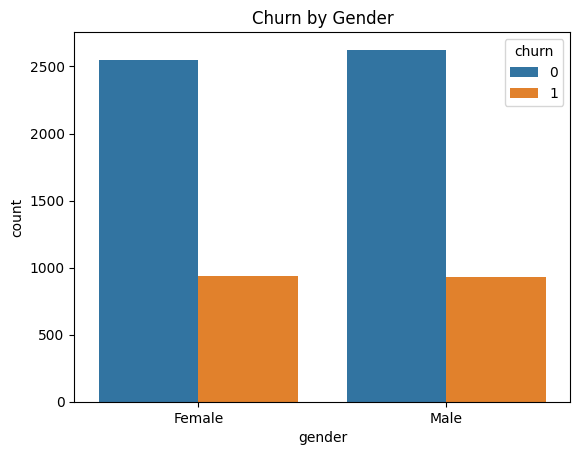

In [21]:
sns.countplot(data=df, x='gender', hue='churn')
plt.title('Churn by Gender')
plt.show()

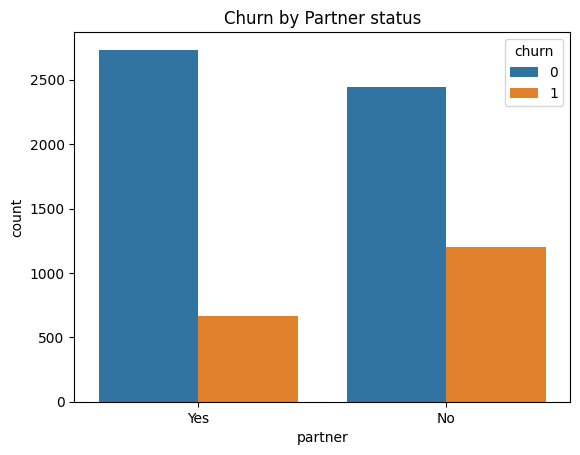

In [22]:
sns.countplot(data=df, x='partner', hue='churn')
plt.title('Churn by Partner status')
plt.show()

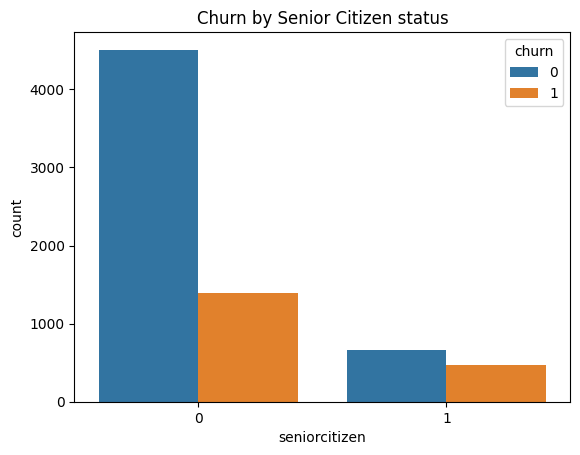

In [23]:
sns.countplot(data=df, x='seniorcitizen', hue='churn')
plt.title('Churn by Senior Citizen status')
plt.show()

### Contract / InternetService / PaymentMethod

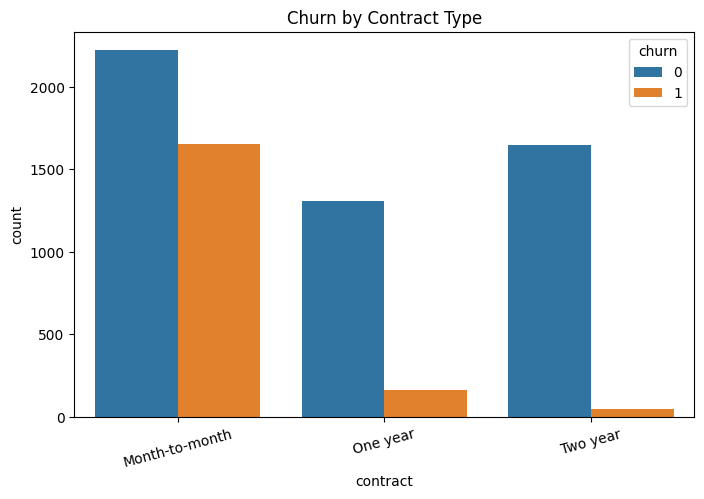

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='contract', hue='churn')
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

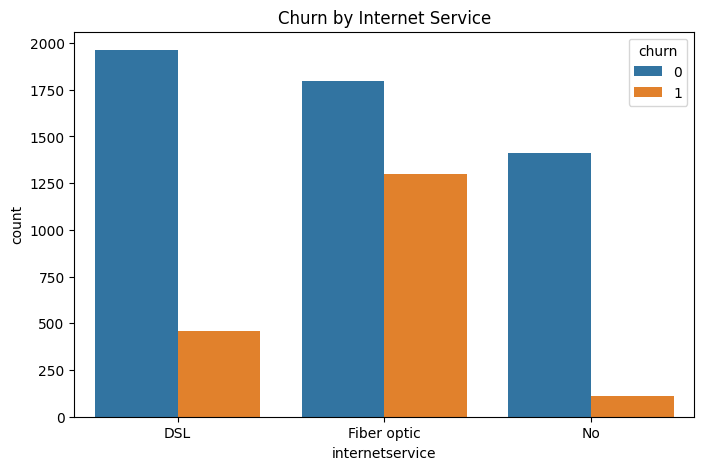

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='internetservice', hue='churn')
plt.title('Churn by Internet Service')
plt.show()

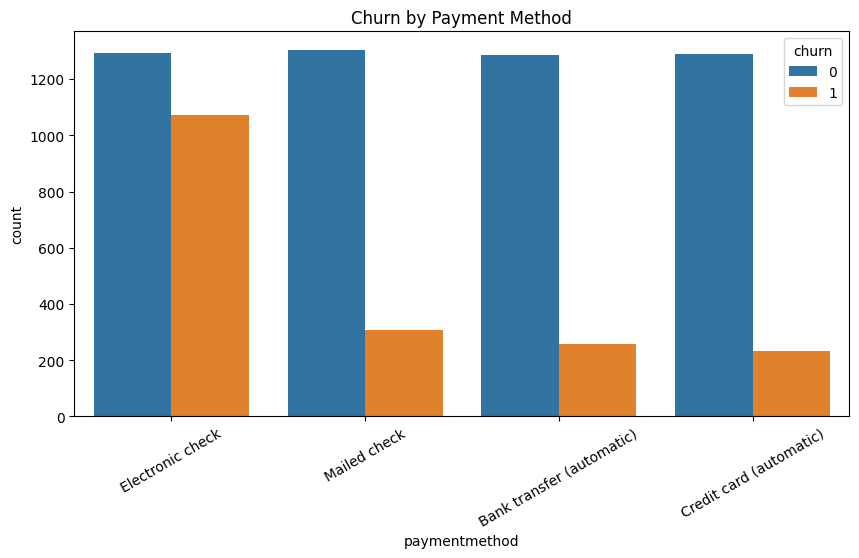

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='paymentmethod', hue='churn')
plt.title('Churn by Payment Method')
plt.xticks(rotation=30)
plt.show()

In [27]:
df[numerical].corrwith(df.churn)

,0
tenure,-0.352229
monthlycharges,0.193356
totalcharges,-0.199484


### Tenure / Monthly / Total Charges مقابل Churn

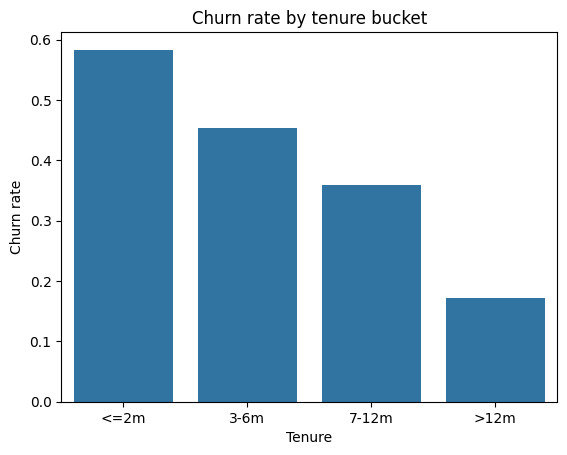

In [28]:
t1 = df[df['tenure'] <= 2].churn.mean()
t2 = df[(df['tenure'] > 2) & (df['tenure'] <= 6)].churn.mean()
t3 = df[(df['tenure'] > 6) & (df['tenure'] <= 12)].churn.mean()
t4 = df[df['tenure'] > 12].churn.mean()

sns.barplot(x=['<=2m','3-6m','7-12m','>12m'], y=[t1,t2,t3,t4])
plt.title('Churn rate by tenure bucket')
plt.xlabel('Tenure')
plt.ylabel('Churn rate')
plt.show()

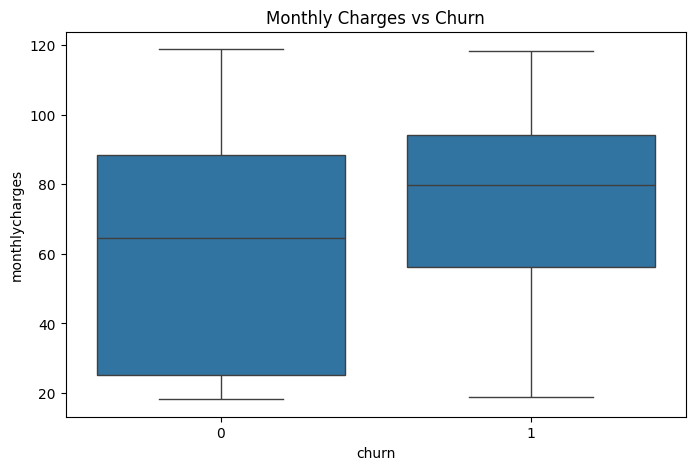

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='churn', y='monthlycharges')
plt.title('Monthly Charges vs Churn')
plt.show()

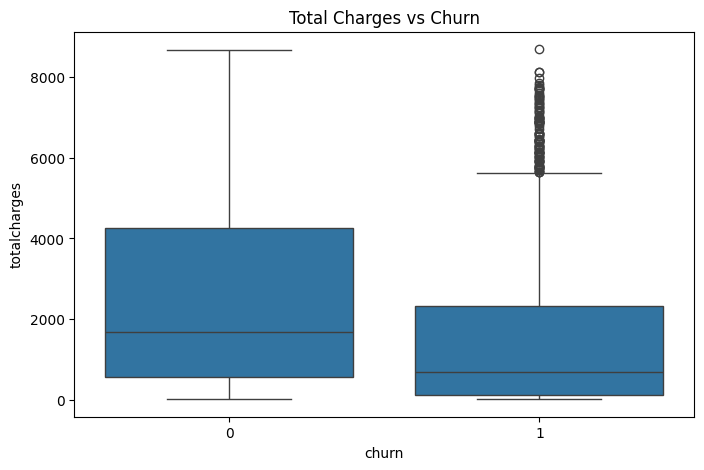

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='churn', y='totalcharges')
plt.title('Total Charges vs Churn')
plt.show()

## 5. تقسيم البيانات (Train / Test)

In [31]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

y_train = df_train['churn'].values
y_test = df_test['churn'].values

x_train = df_train.drop('churn', axis=1)
x_test = df_test.drop('churn', axis=1)

print(x_train.shape, x_test.shape)

(5634, 19) (1409, 19)


## 6. Imputation لـ TotalCharges (بعد السبليت فقط، mean من train بس)

In [32]:
train_mean_tc = x_train['totalcharges'].mean()

x_train['totalcharges'] = x_train['totalcharges'].fillna(train_mean_tc)
x_test['totalcharges'] = x_test['totalcharges'].fillna(train_mean_tc)

print(x_train['totalcharges'].isnull().sum(), x_test['totalcharges'].isnull().sum())

0 0


## 7. Encoding + Scaling في ColumnTransformer واحد


In [33]:
preprocessor = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore'), categorical),
    (StandardScaler(), numerical),
    remainder='drop',
    verbose_feature_names_out=False
)

x_train_proc = preprocessor.fit_transform(x_train)
x_test_proc = preprocessor.transform(x_test)

feature_names = preprocessor.get_feature_names_out()
x_train = pd.DataFrame(x_train_proc, columns=feature_names, index=x_train.index)
x_test = pd.DataFrame(x_test_proc, columns=feature_names, index=x_test.index)

x_train.head()

,gender_Male,seniorcitizen_1,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,...,streamingmovies_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,tenure,monthlycharges,totalcharges
3738,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.102371,-0.521976,-0.263883
3151,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.711743,0.337478,-0.505435
4860,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.793155,-0.809013,-0.751862
3867,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,-0.263980,0.284384,-0.174283
3810,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.281624,-0.676279,-0.991526


## 8. تدريب الموديلات وتقييمها بمتريكس كاملة

In [34]:
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(class_weight='balanced', random_state=42),
}

rows = []
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_churn": precision_score(y_test, y_pred, pos_label=1),
        "recall_churn": recall_score(y_test, y_pred, pos_label=1),
        "f1_churn": f1_score(y_test, y_pred, pos_label=1),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

comparison_df = pd.DataFrame(rows).set_index('model')
comparison_df

--- LogisticRegression ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

--- KNN ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.55      0.55      0.55       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.76      0.76      0.76      1409

--- RandomForest ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg  

,accuracy,precision_churn,recall_churn,f1_churn,roc_auc
model,,,,,
LogisticRegression,0.738822,0.505172,0.783422,0.614256,0.841546
KNN,0.762952,0.553763,0.550802,0.552279,0.793263
RandomForest,0.791341,0.640845,0.486631,0.553191,0.822205


### اختيار أفضل موديل (F1 لفئة churn=1)

In [35]:
selection_metric = 'f1_churn'
best_model_name = comparison_df[selection_metric].idxmax()
best_model = models[best_model_name]

print('أفضل موديل حسب', selection_metric, ':', best_model_name)
comparison_df.sort_values(selection_metric, ascending=False)

أفضل موديل حسب f1_churn : LogisticRegression


,accuracy,precision_churn,recall_churn,f1_churn,roc_auc
model,,,,,
LogisticRegression,0.738822,0.505172,0.783422,0.614256,0.841546
RandomForest,0.791341,0.640845,0.486631,0.553191,0.822205
KNN,0.762952,0.553763,0.550802,0.552279,0.793263


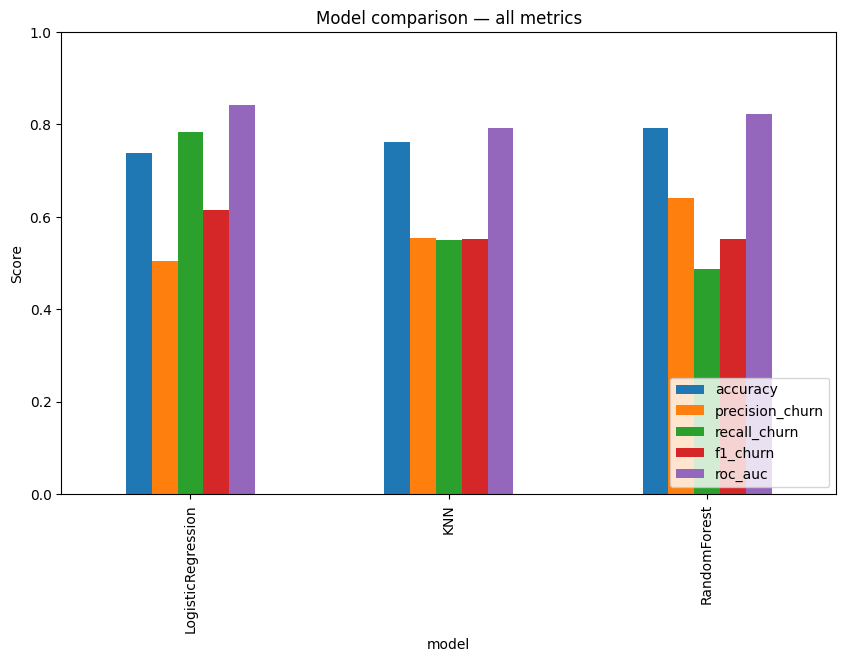

In [36]:
comparison_df[['accuracy','precision_churn','recall_churn','f1_churn','roc_auc']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Model comparison — all metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

### ROC Curve للموديلات التلاتة

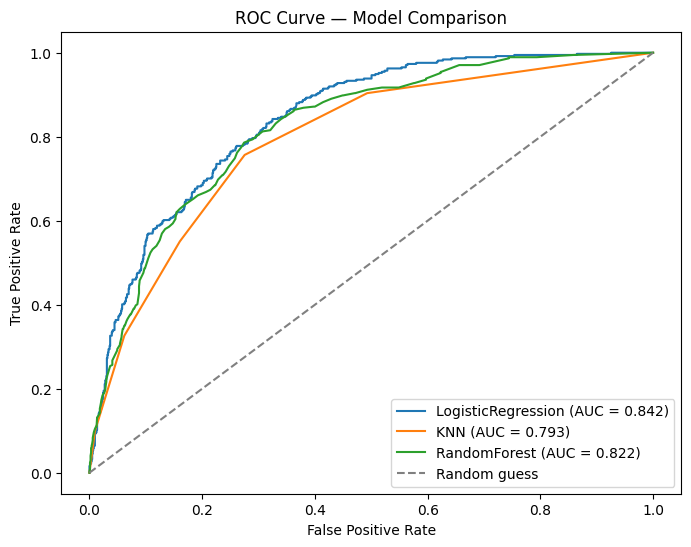

In [37]:
plt.figure(figsize=(8,6))

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = comparison_df.loc[name, 'roc_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.show()

### Confusion Matrix — أفضل موديل

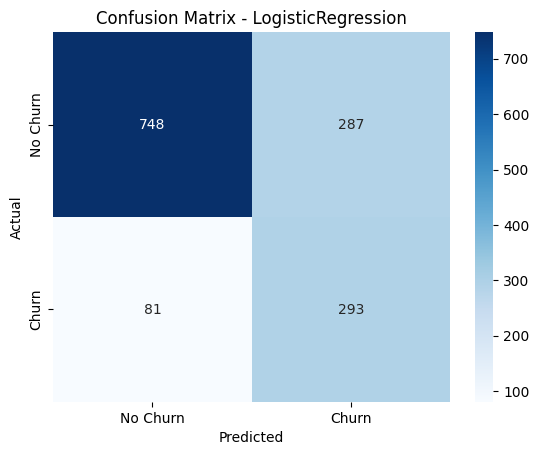

In [38]:
cm = confusion_matrix(y_test, predictions[best_model_name])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

### أهم الأعمدة تأثيرًا — بناءً على أفضل موديل فعليًا

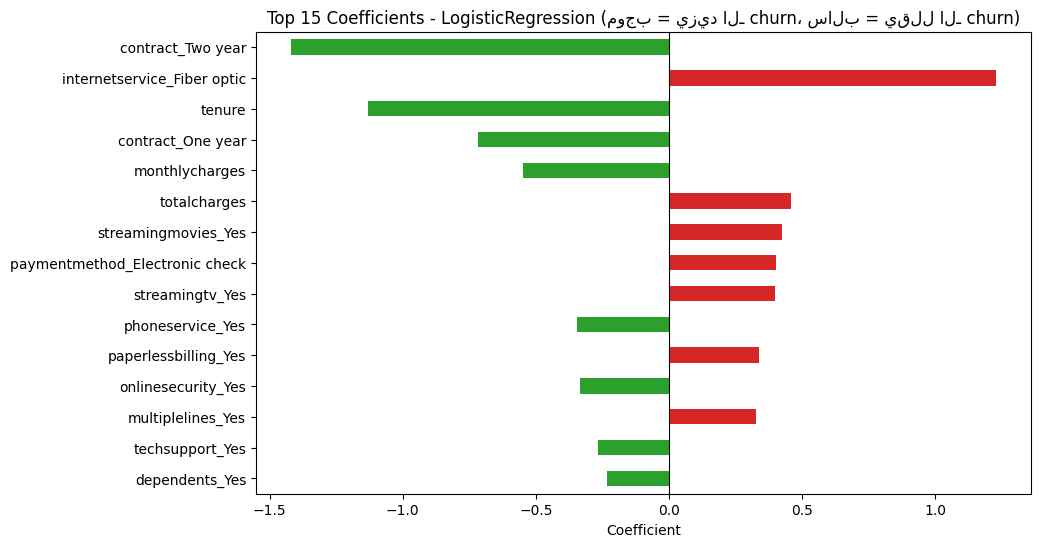

In [39]:
if best_model_name == 'RandomForest':
    importances = pd.Series(best_model.feature_importances_, index=x_train.columns)
    importances = importances.sort_values(ascending=False).head(15)
    title = 'Top 15 Feature Importances - RandomForest'
elif best_model_name == 'LogisticRegression':
    coefs = pd.Series(best_model.coef_[0], index=x_train.columns)
    # نرتب حسب حجم التأثير (abs)، لكن نعرض القيمة بعلامتها الأصلية
    # موجب = بيزود احتمال الـ churn | سالب = بيقلل احتمال الـ churn
    importances = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)
    title = 'Top 15 Coefficients - LogisticRegression (موجب = يزيد الـ churn، سالب = يقلل الـ churn)'
else:
    importances = None
    title = None
    print(f'{best_model_name} مفيهاش feature importance مباشرة (KNN).')

if importances is not None:
    plt.figure(figsize=(10,6))
    colors = ['#d62728' if v > 0 else '#2ca02c' for v in importances] if best_model_name == 'LogisticRegression' else None
    importances.plot(kind='barh', color=colors)
    plt.title(title)
    plt.xlabel('Importance' if best_model_name != 'LogisticRegression' else 'Coefficient')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.gca().invert_yaxis()
    plt.show()

## 9. الخلاصة

In [40]:
best_row = comparison_df.loc[best_model_name]

print(f"أفضل موديل حسب {selection_metric}: {best_model_name}")
print(f"Accuracy        : {best_row['accuracy']:.3f}")
print(f"Precision(churn): {best_row['precision_churn']:.3f}")
print(f"Recall(churn)   : {best_row['recall_churn']:.3f}")
print(f"F1(churn)       : {best_row['f1_churn']:.3f}")
print(f"ROC-AUC         : {best_row['roc_auc']:.3f}")

if importances is not None:
    print("\nأهم 5 عوامل مؤثرة في القرار:")
    print(importances.head(5))

أفضل موديل حسب f1_churn: LogisticRegression
Accuracy        : 0.739
Precision(churn): 0.505
Recall(churn)   : 0.783
F1(churn)       : 0.614
ROC-AUC         : 0.842

أهم 5 عوامل مؤثرة في القرار:
contract_Two year             -1.420053
internetservice_Fiber optic    1.227827
tenure                        -1.131932
contract_One year             -0.717959
monthlycharges                -0.547897
dtype: float64


In [41]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Preprocessing for deployment
deployment_preprocessor = make_column_transformer(
    (
        Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]),
        numerical
    ),
    (
        OneHotEncoder(drop='first', handle_unknown='ignore'),
        categorical
    ),
    remainder='drop',
    verbose_feature_names_out=False
)

# Final model = preprocessing + Logistic Regression
deployment_model = Pipeline([
    ('preprocessor', deployment_preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

# Train the complete pipeline on the original training data
deployment_model.fit(
    df_train.drop('churn', axis=1),
    df_train['churn']
)

# Save the model
joblib.dump(deployment_model, 'telco_churn_model.pkl')

print("Model saved successfully!")

Model saved successfully!
